In [3]:
using ITensors
using ITensorMPS
using Random
using LinearAlgebra
using Statistics
using PrettyTables
using Plots

In [4]:
function density_operators(N, psi, sites)
    upd = fill(0.0, N)
    dnd = fill(0.0, N)
    updn = fill(0.0, N) 
    for j in 1:N
        orthogonalize!(psi, j)
        psidag_j = dag(prime(psi[j], "Site"))
        
        upd[j] = scalar(psidag_j * op(sites, "Nup", j) * psi[j])
        dnd[j] = scalar(psidag_j * op(sites, "Ndn", j) * psi[j])
        updn[j] = scalar(psidag_j * op(sites, "Nupdn", j) * psi[j])
    end
    return upd, dnd, updn
end

# Von Neumann entropy in bits - configuration space.
function von_neumann_entropy(rho; atol=1e-12)
    vals = eigen(Hermitian(rho)).values
    vals = vals[vals .> atol]
    return -sum(vals .* log.(vals)), -sum(vals .* log2.(vals))
end

function build_1_particle_rdm(state)
    
    L = length(state)
    #=  
        N and not L since any site can have spin up or down
    =#
    rho_1 = zeros(ComplexF64, 2*L, 2*L) 

    Cupup = correlation_matrix(state, "Cdagup", "Cup")
    Cdndn = correlation_matrix(state, "Cdagdn", "Cdn")
    Cupdn = correlation_matrix(state, "Cdagup", "Cdn")
    Cdnup = correlation_matrix(state, "Cdagdn", "Cup")   

    for i in 1:L
        for j in 1:L
            rho_1[i, j] = Cupup[i,j]
            rho_1[i, j + L] = Cupdn[i,j]
            rho_1[i + L, j] = Cdnup[i,j]
            rho_1[i + L, j + L] = Cdndn[i,j]
        end 
    end
    return rho_1 = rho_1 / L
end

function random_metallic_state(L, Nup, Ndn)
    state = fill("Emp", L)
    p = Nup + Ndn
    for i in 1:L
        j = L - i
        if(p > j)
            state[j] = "UpDn"
            p -= 2
        elseif (p > 0) 
            state[j] = j % 2 == 1 ? "Up" : "Dn"
            p -= 1
        end
    end
    return state
end

function H_EHM(N, J, U, V, sites)
    os = OpSum()
    for i in 1:(N - 1)
      # Knetic 
      os -= J, "Cdagup", i, "Cup", i + 1
      os -= J, "Cdagup", i + 1, "Cup", i
      os -= J, "Cdagdn", i, "Cdn", i + 1
      os -= J, "Cdagdn", i + 1, "Cdn", i
      # Nearest-neighbours
      os += V, "Ntot", i, "Ntot", i + 1
    end
    # on-site
    for i in 1:N
      os += U, "Nupdn", i
    end
    return MPO(os, sites)
end

function random_metallic_state(L, Nup, Ndn)
    state = fill("Emp", L)
    p = Nup + Ndn
    for i in 1:L
        j = L - i
        if(p > j)
            state[j] = "UpDn"
            p -= 2
        elseif (p > 0) 
            state[j] = j % 2 == 1 ? "Up" : "Dn"
            p -= 1
        end
    end
    return state
end

function random_cdw_state(L, Nup, Ndn)
    state = fill("Emp", L)
    Nup_extra = Int.(Nup % Ndn)
    for i in 1:2:(L - Nup_extra)
        state[i] = "UpDn"
        Nup-=1
    end
    if Nup != 0
        state[L] = "Up"
    end
    return state
end 
function random_sdw_state(L, Nup, Ndn)
    state = fill("Emp", L)
    Nup_extra = Int.(Nup % Ndn)
    for i=1:2:(L-Nup_extra)
        state[i] = "Up"
        state[i+1] = "Dn"
    end
    if Nup != 0 
        state[L] = "Up"
    end
    return state 
end


function random_ps_state(L, Nup, Ndn)
    state = fill("Emp", L)
    
    Ndbl = min(Nup, Ndn)
    Nup -= Ndbl
    Ndn -= Ndbl
    
    for i in 1:Ndbl
        state[i] = "UpDn"
    end
    
    next_site = Ndbl + 1
    
    if Nup > 0
        state[next_site] = "Up"
        next_site += 1
    elseif Ndn > 0
        state[next_site] = "Dn"
        next_site += 1
    end
    return state
end

random_ps_state (generic function with 1 method)

In [5]:
function get_region(u, v)

    alpha = 0.5
    # Boundary functions
    get_metallic_lower_boundary(u) = u <= 0 ? -exp(alpha * u) : -alpha * u - 1.0
    get_metallic_upper_boundary_h(u) = -0.1 * u
    get_metallic_upper_boundary_negative(u) = -2.5 * alpha * u

    lower = get_metallic_lower_boundary(u)
    upper_h = get_metallic_upper_boundary_h(u)
    upper_neg = get_metallic_upper_boundary_negative(u)

    if v <= lower
        return "PS"
    elseif (u < 0 && v < 0 && v > lower) ||
           (u > 0 && v > 0 && v < upper_h) ||
           (u > 0 && v < 0 && v > lower && v < upper_neg)
        return "METALLIC"
    elseif (u < 0 && v > 0) ||
           (u > 0 && v > 0 && v >= 2 * u)
        return "CDW"
    elseif (u > 0 && v < 0 && v > lower) ||
           (u > 0 && v > 0 && v >= upper_h && v < 2 * u)
        return "SDW"
    end
    return "PS"
end
function state_ehm_diagram(L, Nup, Ndn, U, V; epsilon=1e-2)

    state = fill("Emp", L)
    
    region = get_region(U, V)

    @show region

    # Weak coupling = metallic
    if region == "METALLIC" 
        state = random_metallic_state(L, Nup, Ndn)
    # CDW
    elseif region == "CDW"
        state = random_cdw_state(L, Nup, Ndn)
    elseif region == "SDW"
        state = random_sdw_state(L, Nup, Ndn)
    else
        state = random_ps_state(L, Nup, Ndn)
    end
    return state
end

state_ehm_diagram (generic function with 1 method)

In [6]:
function magnetization_from_rdm(rdm, L)
    magnetization_density_matrix = fill(0.0, L)
    dim = floor(Int, rdm.size[1]//2)
    @show dim
    for i in 1:dim 
        magnetization_density_matrix[i] = 0.5 * (rdm[i, i] - rdm[i + dim, i + dim]) 
    end 
    @show magnetization_density_matrix * L
    return magnetization_density_matrix * L
end
function quantum_coherence(rho)
    dim = size(rho)[1]
    C = 0.0
    for i in 1:dim
        for j in (i+1):dim
            # maybe return here and force hermitian()
            C += abs(rho[i, j])
        end
    end
    return C 
end

quantum_coherence (generic function with 1 method)

states = ["Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn", "Up"]
┌─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┬─────────────────┬───────────┐
│          Col. 1 │    Col. 2 │          Col. 3 │    Col. 4 │          Col. 5 │    Col. 6 │          Col. 7 │    Col. 8 │          Col. 9 │   Col. 10 │         Col. 11 │   Col. 12 │         Col. 13 │   Col. 14 │         Col. 15 │   Col. 16 │         Col. 17 │   Col. 18 │         Col. 19 │   Col. 20 │         Col. 21 │   Col. 22 │
├─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼───────────┼─────────────────┼─

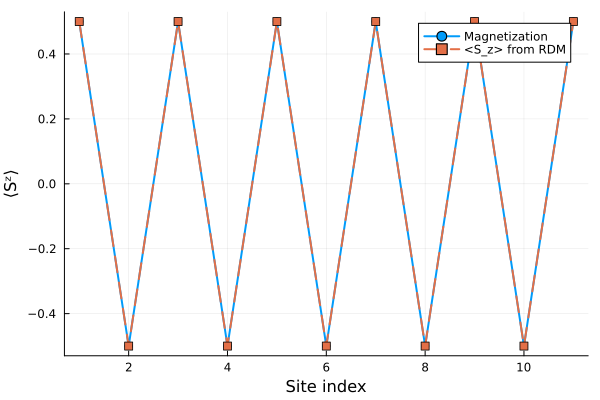

In [7]:
L = 11

Npart = floor(Int, L/2) 
Nup = Npart + L % 2 
Ndn = L - Nup 

sites = siteinds("Electron", L; conserve_qns=true)
states = fill("Emp", L)
states = [isodd(j) ? "Up" : "Dn" for j in 1:L]

@show states

psi = productMPS(sites,states)

rho_1_matrix = build_1_particle_rdm(psi)

@pt rho_1_matrix
@show ishermitian(rho_1_matrix)
@show tr(rho_1_matrix)

nup, ndn, nupdn = density_operators(L, psi, sites)
magnetization = 0.5 * (nup - ndn)

magnetization_rdm = magnetization_from_rdm(rho_1_matrix, L)

L = length(magnetization)
sites = 1:L
plot(sites, magnetization;
     label = "Magnetization",
     lw = 2,
     marker = :circle,
     xlabel = "Site index",
     ylabel = "⟨Sᶻ⟩",
     legend = :topright)

plot!(sites, magnetization_rdm;
      label = "<S_z> from RDM",
      lw = 2,
      marker = :square,
      linestyle = :dash)

# testing for DMRG


In [12]:
using LinearAlgebra
# Von Neumann entropy in bits = configuration space.
function von_neumann_entropy(rho; atol=1e-12)
    vals = eigen(Hermitian(rho)).values
    vals = vals[vals .> atol]
    return -sum(vals .* log.(vals)), -sum(vals .* log2.(vals))
end

function quantum_coherence(rho)
    dim = size(rho)[1]
    C = 0.0
    for i in 1:dim
        for j in (i+1):dim
            # maybe return here and force hermitian()
            C += abs(rho[i, j])
        end
    end
    return C 
end

quantum_coherence (generic function with 1 method)

In [16]:
L = 6
sites = siteinds("Electron", L; conserve_qns=true)

Npart = floor(Int, L/2)
Nup = Npart + L % 2 
Ndn = L - Nup 

J = 1.0
U = -4.0
V = 6.0

H = H_EHM(L, J, U, V, sites)

nsweeps = 10
maxdims = [50, 100, 200, 400, 800, 800, 1000, 12000]
cutoffs = [1E-14]

states = state_ehm_diagram(L, Nup, Ndn, U, V)
psi0 = random_mps(sites, states; linkdims=10)

@show flux(psi0)

energy, psi = dmrg(H, psi0; nsweeps, maxdim=maxdims, cutoff=cutoffs)

upd, dnd, updn = density_operators(L, psi, sites)

@show nup
@show ndn
@show updn

region = "CDW"
flux(psi0) = QN(("Nf",6,-1),("Sz",0))
After sweep 1 energy=-12.7036742140738  maxlinkdim=50 maxerr=4.54E-11 time=0.088
After sweep 2 energy=-12.787693074262387  maxlinkdim=63 maxerr=5.41E-15 time=0.079
After sweep 3 energy=-12.834400506791264  maxlinkdim=61 maxerr=7.66E-15 time=0.069
After sweep 4 energy=-12.857782683571939  maxlinkdim=61 maxerr=9.14E-15 time=0.074
After sweep 5 energy=-12.871382801252862  maxlinkdim=61 maxerr=4.66E-15 time=0.075
After sweep 6 energy=-12.874907610436395  maxlinkdim=54 maxerr=7.26E-15 time=0.076
After sweep 7 energy=-12.875575483161558  maxlinkdim=56 maxerr=7.83E-15 time=0.071
After sweep 8 energy=-12.875608885290287  maxlinkdim=57 maxerr=8.91E-15 time=0.080
After sweep 9 energy=-12.875609589442208  maxlinkdim=45 maxerr=8.15E-15 time=0.071
After sweep 10 energy=-12.875609605162436  maxlinkdim=45 maxerr=6.98E-15 time=0.068
nup = [1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
ndn = [0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0,

6-element Vector{Float64}:
 0.8545280537614786
 0.12617554387410176
 0.4844098687710483
 0.48427071727330806
 0.126242119995048
 0.8544565462703307

quantum_coherence(rho_1_matrix) = 0.15264149883171593
S = 2.2510699531873337
E_p = 1.152457664519224
dim = 6
magnetization_density_matrix * L = [1.3080538868726066e-7, -1.2346170727428607e-7, -2.0679239670640115e-7, 1.9625661437649988e-7, -2.1677936071218262e-8, 2.4870037029778302e-8]


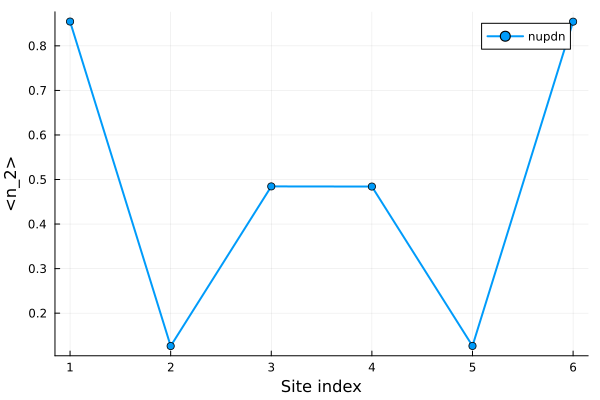

In [15]:
rho_1_matrix = build_1_particle_rdm(psi)
# @pt rho_1_matrix
@show quantum_coherence(rho_1_matrix)


S, _ = von_neumann_entropy(rho_1_matrix)
E_p = S - log(L//2)


@show S

@show E_p

magnetization = 0.5 * (nup - ndn)
magnetization_rdm = magnetization_from_rdm(rho_1_matrix, L)

L = length(updn)
sites = 1:L

plot(sites, updn;
     label = "nupdn",
     lw = 2,
     marker = :circle,
     xlabel = "Site index",
     ylabel = "<n_2>",
     legend = :topright)